In [ ]:
!pip install shap

# Previsão de Burnout - Redes Neurais (MLP)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import warnings
import shap

warnings.filterwarnings('ignore')

## 1. Carregamento e Preparação dos Dados


In [ ]:
# Carregamento do dataset
dataset_path = 'mental_health_burnout_prediction_dataset.csv'
try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    print("Por favor, faça o upload do arquivo 'mental_health_burnout_prediction_dataset.csv' no Colab.")

if 'df' in locals():
    # Remover colunas desnecessárias
    df = df.drop(columns=['Person_ID', 'AI_Wellness_Recommendation'])

    # Binarizar o Target (High/Critical -> 1, Low/Moderate -> 0)
    df['Burnout_Risk_Binary'] = df['Burnout_Risk'].apply(lambda x: 1 if x in ['High', 'Critical'] else 0)

    X = df.drop(columns=['Burnout_Risk', 'Burnout_Score', 'Burnout_Risk_Binary'])
    y = df['Burnout_Risk_Binary']

    # Identificar colunas numéricas e categóricas
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X.select_dtypes(exclude=['int64', 'float64']).columns

    # Tratar valores nulos (estritamente pandas)
    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())
    for col in cat_cols:
        X[col] = X[col].fillna(X[col].mode()[0])

    # Converter categóricas (One-Hot Encoding)
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # Divisão Treino e Teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Dados preparados com sucesso!")

Dados preparados com sucesso!


## 2. Normalização e Treinamento do Modelo (MLP)

In [ ]:
if 'df' in locals():
    # Normalizando os dados
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Criando e Treinando o Modelo
    mlp = MLPClassifier(hidden_layer_sizes=(64, 32),
                        max_iter=500,
                        activation='relu',
                        solver='adam',
                        random_state=42,
                        early_stopping=True,
                        validation_fraction=0.1)

    print("Treinando o modelo MLPClassifier...")
    mlp.fit(X_train_scaled, y_train)

    print("Accuracy on training set: {:.2f}".format(mlp.score(X_train_scaled, y_train)))
    print("Accuracy on test set: {:.2f}".format(mlp.score(X_test_scaled, y_test)))

Treinando o modelo MLPClassifier...
Accuracy on training set: 0.99
Accuracy on test set: 0.99


## Salvando o Modelo Treinado

In [ ]:
import joblib

if 'mlp' in locals():
    model_filename = 'mlp_burnout_prediction_model.joblib'
    joblib.dump(mlp, model_filename)
    print(f"Modelo salvo como '{model_filename}'")
else:
    print("O modelo 'mlp' não foi encontrado. Por favor, execute as células anteriores para treiná-lo.")

Modelo salvo como 'mlp_burnout_prediction_model.joblib'


## 3. Resultados (Curva de Loss)

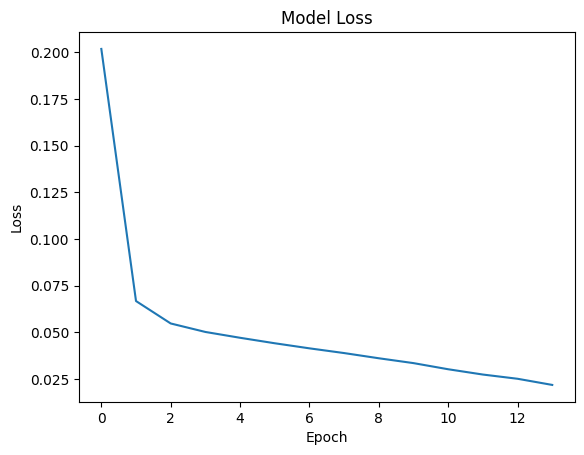

In [ ]:
"""## 3. Resultados (Curvas de Loss e Acurácia)"""

if 'df' in locals():
    # Plot da Curva de Loss
    plt.figure()
    plt.plot(mlp.loss_curve_, color='red')
    plt.title("Curva de Loss (Perda)")
    plt.ylabel("Loss")
    plt.xlabel("Época")
    plt.show()

    # Plot da Curva de Acurácia (Validação)
    plt.figure()
    plt.plot(mlp.validation_scores_, color='blue')
    plt.title("Curva de Acurácia (Validação)")
    plt.ylabel("Acurácia")
    plt.xlabel("Época")
    plt.show()


## 4. Avaliação do Modelo e Matriz de Confusão


Resultados da Avaliação:
Acurácia: 0.9863
Precisão: 0.9870721352456603
Sensibilidade: 0.9863
F1-Score: 0.9864569056873499


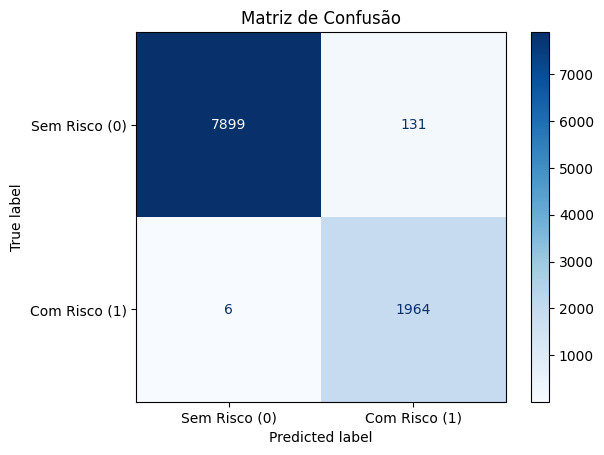

In [ ]:
if 'df' in locals():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
    output_model_ = mlp.predict(X_test_scaled)
    print('\nResultados da Avaliação:')
    print('Acurácia:', accuracy_score(y_test, output_model_))
    print('Precisão:', precision_score(y_test, output_model_, average='weighted'))
    print('Sensibilidade:', recall_score(y_test, output_model_, average='weighted'))
    print('F1-Score:', f1_score(y_test, output_model_, average='weighted'))
    cm = confusion_matrix(y_test, output_model_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Risco (0)', 'Com Risco (1)'])
    disp.plot(cmap=plt.cm.Blues)
    disp.ax_.set_title('Matriz de Confusão')
    plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

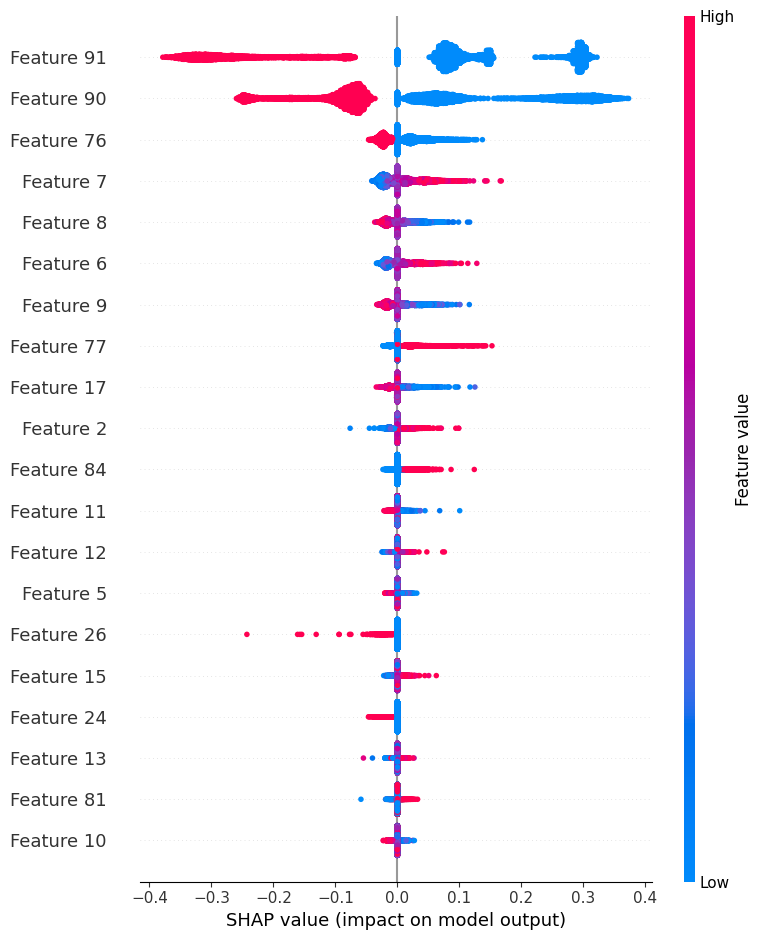

In [ ]:
if 'df' in locals():
    # K-means para otimizar a velocidade do SHAP
    X_train_summary = shap.kmeans(X_train_scaled, 10)
    explainer = shap.KernelExplainer(mlp.predict, X_train_summary)

    # Calculando os valores SHAP
    shap_values = explainer.shap_values(X_test_scaled)

    # 1. Trocando "Feature X" para "Variável X" (Eixo Y)
    nomes_variaveis = [f"Variável {i}" for i in range(X_test_scaled.shape[1])]

    # Se você quiser que apareça o NOME REAL da coluna (ex: Age, Gender) em vez de "Variável 1",
    # basta apagar a linha de cima e descomentar a linha de baixo:
    # nomes_variaveis = X.columns

    shap.summary_plot(shap_values, X_test_scaled, feature_names=nomes_variaveis, show=False)

    # 2. Traduzindo a barra lateral (Feature Value) e o eixo X
    fig = plt.gcf()
    if len(fig.axes) > 1:
        cax = fig.axes[-1]  # Pega a barra de cores lateral
        cax.set_ylabel('Valor da Variável', fontsize=12)

    plt.xlabel("Valor SHAP (Impacto na predição)")
    plt.show()
